## Load Libraries

In [55]:
import matplotlib.pyplot as plt
import random
from search import Problem, best_first_graph_search,astar_search, depth_first_graph_search

## Define nodes and edges
some edges with an arrow indicate that they can only be traversed in one direction. 
For instance, one can traverse directly from Node 2 to Node 1 but one cannot traverse directly from Node 1 to
Node 2. Please consider taking a look at the assignment sheet for the position of the nodes and edges

In [56]:
nodes = {
    '1': (4,1),
    '2': (2,2),
    '3': (4,4),
    '4': (6,3),
    '5': (5,6),
    '6': (7,5)
 }
edges = {
    '1':[('3',5),('4',6)],
    '2':[('1',4),('3',4)],
    '3':[('1',5),('2',5),('5',6),('6',7)],
    '4':[('1',6),('3',5),('5',7)],
    '5':[('3',6),('4',8)],
    '6':[('3',7)]
 }

In [57]:
def draw_graph(nodes, graph):
    plt.figure()

    # Draw edges with weights (simple line + text)
    for node in graph:
        for neighbor, weight in graph[node]:
            x1, y1 = nodes[node]
            x2, y2 = nodes[neighbor]

            # line
            plt.plot([x1, x2], [y1, y2])

    # Draw nodes
    for node, (x, y) in nodes.items():
        plt.scatter(x, y, s=600)
        plt.text(x, y, node, ha='center', va='center')

    plt.title("Weighted Graph")
    plt.axis('equal')
    plt.show()

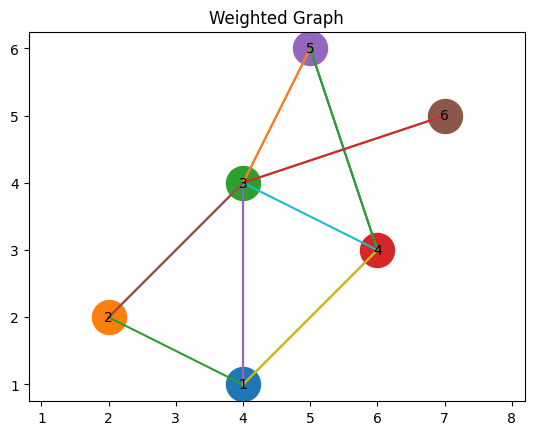

In [58]:
draw_graph(nodes, edges)

## Problem formulation
This class defines a search problem for graph traversal.

- State: a node in the graph (e.g., '1', '2', '3')
- Action: moving from one node to its neighboring node
- Result: the next node reached after taking an action
- Goal test: checks whether the current node is the target node

This formulation allows BFS to operate on the graph using AIMA's search framework.

In [59]:
graph = { 
    '1': ['3', '4'],
    '2': ['1', '3'],
    '3': ['1', '2', '5', '6'],
    '4': ['1', '3', '5'],
    '5': ['3', '4'],
    '6': ['3']
}
class GraphProblem(Problem):
    def __init__(self, initial, goal=None):
        super().__init__(initial, goal)

    def actions(self, state):
        return graph[state]

    def result(self, state, action):
        return action

    def goal_test(self, state):
        return state == self.goal

## solve the problem
visualize the output based on algorithm that you choose.

In [60]:
problem = GraphProblem('2','5')

solution = astar_search(problem, lambda node: node.path_cost, display=True)


print(f"Solution path: {solution.solution()}")
print(f"Path depth: {solution.depth}")
print(f"Total path cost: {solution.path_cost}")
print(f"Full node path: {[node.state for node in solution.path()]}")

print(solution.solution())

4 paths have been expanded and 1 paths remain in the frontier
Solution path: ['3', '5']
Path depth: 2
Total path cost: 2
Full node path: ['2', '3', '5']
['3', '5']
